# FinMark Corporation – Machine Learning Solution Project
## Team 2 : Obinguar Armielyn & Penaflor Christian

## Introduction

As FinMark Corporation’s data analyst, the goal is to design a **machine learning solution** that helps address challenges in data analysis and insight generation. This project will be completed over a **12-week timeline** and will be delivered in three major phases:

- **Milestone 1: Exploratory Data Analysis (EDA)**  
  Conduct a thorough exploration of the collected datasets to understand their structure, highlight key patterns, detect anomalies, and assess overall data quality.  

- **Milestone 2: Data Visualization**  
  Create insightful visualizations that uncover relationships between variables, highlight emerging trends, and support deeper understanding of customer behavior and market dynamics.  

- **Terminal Assessment: Machine Learning Solution Presentation**  
  Develop and deliver a comprehensive presentation documenting the process, insights, and proposed machine learning solution. This will include the approach to EDA, visualization outcomes, challenges encountered, and key findings.  

---

## Available Datasets

The following datasets are provided for this project and will be used consistently across all milestones:

1. **Customer Segments** – demographic details of FinMark’s customers.  
2. **Customer Transactions** – purchase history and transaction-level details.  
3. **Social Media Interactions** – customer engagement and sentiment data from online platforms.  

These datasets form the foundation of the analysis, visual exploration, and eventual machine learning modeling.


## Import Libraries

In [1]:
import os
import math
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inline plotting
%matplotlib inline

# Display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

In [2]:
# Set global style
sns.set_theme(style="whitegrid")


custom_palette = sns.color_palette("crest", as_cmap=False)
sns.set_palette(custom_palette)

In [3]:
df = pd.read_csv("final_merged_dataset.csv")

TARGET = None
MAX_NUMERIC_PLOTS = 20
TOP_CATS = 10

print("Data loaded successfully!")
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

Data loaded successfully!
Shape: (2667, 17)


,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod,IsHighSpender,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
0,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,504a03b0-294d-4e3c-9bf7-46935ba6c47a,2023-01-22,496.625,Clothing,Debit Card,0,0626cfe9-8e7f-4b19-ba9b-21330cd007c8,2024-01-11,Instagram,Comment,Negative
1,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,504a03b0-294d-4e3c-9bf7-46935ba6c47a,2023-01-22,496.625,Clothing,Debit Card,0,20320eb9-5f38-41f5-b855-e0a0880d8c46,2023-08-25,Facebook,Share,Positive
2,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,d4922534-dfd9-47d9-8fc8-d0421284b682,2022-09-14,660.870,Home & Garden,Bank Transfer,0,0626cfe9-8e7f-4b19-ba9b-21330cd007c8,2024-01-11,Instagram,Comment,Negative
3,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,d4922534-dfd9-47d9-8fc8-d0421284b682,2022-09-14,660.870,Home & Garden,Bank Transfer,0,20320eb9-5f38-41f5-b855-e0a0880d8c46,2023-08-25,Facebook,Share,Positive
4,5fb09cd8-a473-46f7-80bd-6e49cf509078,45.0,Female,Castilloport,High,2020-07-21,99917043-698e-4753-a1fb-61b4afdd4da3,2022-11-11,976.880,Electronics,Paypal,0,3d962e49-3930-4131-aa8f-ad8753338770,2024-01-01,Instagram,Share,Positive


,dtype
CustomerID,object
Age,float64
Gender,object
Location,object
IncomeLevel,object
SignupDate,object
TransactionID,object
TransactionDate,object
Amount,float64
ProductCategory,object


In [5]:
for col in ["SignupDate", "TransactionDate", "InteractionDate"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [6]:
# Numeric expectations
for col in ["Age", "Amount", "IsHighSpender"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

## Customer Demographics - Visualization

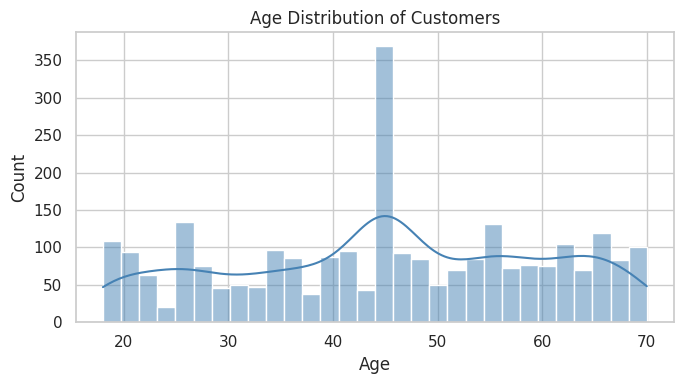

In [7]:
# Age distribution
if "Age" in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
    plt.title("Age Distribution of Customers")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

####

- Insight: The customer base shows a peak density between 40 and 45 years old. This cohort generally represents mid-career, financially stable individuals.
- Recommendation: Targeted Marketing Campaigns: Design and launch product campaigns (e.g., premium services, mid-to-high-value investment/asset protection products) specifically tailored to the 40-45 age group to maximize conversion rates and customer Lifetime Value (LTV).

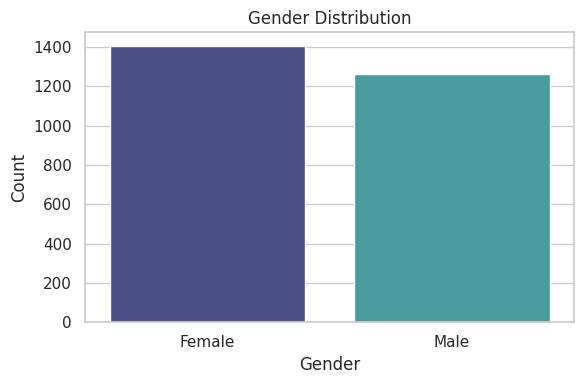

In [12]:
#Gender Distribution
if "Gender" in df.columns:
    df_gender = df[~df["Gender"].isin(["Unknown", "unknown", "Prefer not to say", np.nan])]

    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=df_gender,
        x="Gender",
        order=df_gender["Gender"].value_counts().index,
        palette="mako"
    )
    plt.title("Gender Distribution")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


####

- Gender Distribution
Technical Insight:
The countplot provides a clear, categorical breakdown of the customer base by gender. It shows a dominant representation of one gender (Female), with other genders (Male, and potentially others if not filtered) constituting a significantly smaller portion of the total. This imbalance is a key demographic feature that must be accounted for in any segmentation or predictive analysis.

- Business Insight:
FinMark's brand, product mix, or marketing channels are currently far more effective at attracting and converting Female customers. This could be a result of a historically strong positioning in categories traditionally favored by women (as seen in the next chart), marketing creative that resonates more with a female audience, or partnerships with female-oriented influencers/media. While having a strong core demographic is beneficial, a severe gender imbalance can limit total addressable market and indicate underlying biases in marketing or product development.

- Recommendations:

Leverage Strength: Continue to cultivate the loyal female customer base with high-touch loyalty programs, exclusive previews, and community-building initiatives (e.g., user groups, social media communities).

Diagnose the Gap: Conduct market research to understand why male and non-binary customer acquisition is lower. Analyze marketing channel performance, ad creative, and on-site messaging for unconscious bias.

Strategic Inclusivity: Develop targeted marketing campaigns and product collaborations designed to appeal to a broader male audience. Ensure that all marketing materials are inclusive and represent a diverse range of genders. Review product development pipelines to ensure new offerings have a broad appeal.

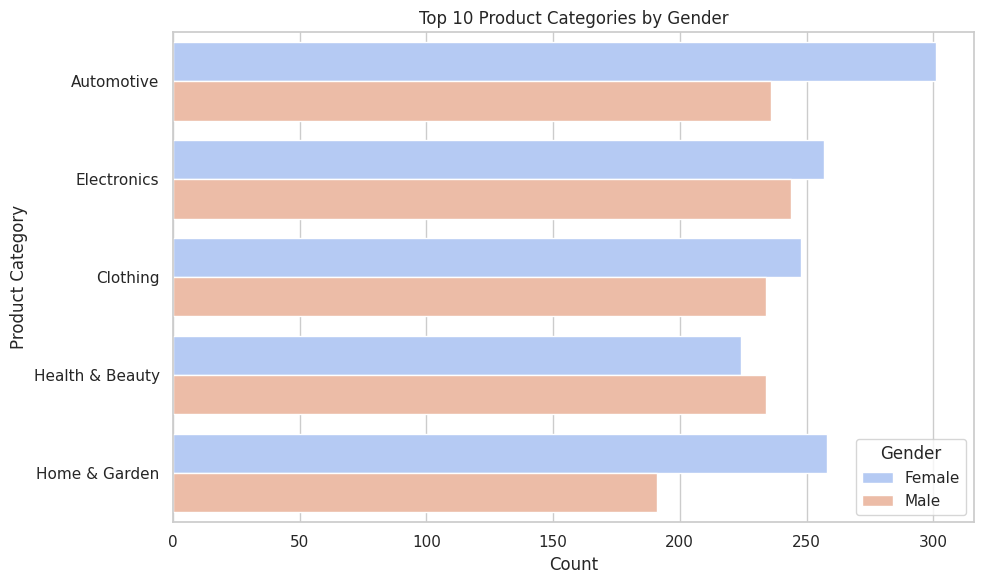

In [14]:
#Gender vs Product Category
if {"Gender", "ProductCategory"}.issubset(df.columns):
    df_gp = df[
        ~df["Gender"].isin(["Unknown", "unknown", "Prefer not to say", np.nan])
        & ~df["ProductCategory"].isin(["Unknown", "unknown", "UNKNOWN", np.nan])
    ]

    top_categories = df_gp["ProductCategory"].value_counts().head(10).index
    df_gp = df_gp[df_gp["ProductCategory"].isin(top_categories)]

    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df_gp,
        y="ProductCategory",
        hue="Gender",
        order=top_categories,
        palette="coolwarm"
    )
    plt.title("Top 10 Product Categories by Gender")
    plt.xlabel("Count")
    plt.ylabel("Product Category")
    plt.legend(title="Gender")
    plt.tight_layout()
    plt.show()


####
* Top 10 Product Categories by Gender
- Technical Insight:
This horizontal stacked bar chart illustrates the interaction between two categorical variables: product category and gender. It not only shows the overall popularity of categories but also how that popularity is driven by different gender segments. The visualization makes it easy to see that while Females are the primary drivers in all top categories, the degree of their dominance varies.

- Business Insight:
The data confirms that Female customers are the primary purchasing force across the entire business. Categories like Clothing and Home & Garden are overwhelmingly driven by women, suggesting they are the key decision-makers for these purchases. The Electronics category shows a relatively higher proportion of Male spenders, though Females still lead in absolute volume. This indicates that while men may be more specialized in their interests, women are making the majority of electronics purchases, possibly for the whole household. This paints a picture of the female customer as the central "household manager" or primary purchaser for FinMark.

- Recommendations:
Cross-Selling and Bundling: Create strategic bundles that leverage female purchasing power. For example, offer a "Home Tech Upgrade" bundle combining Electronics and Home & Garden items, marketed directly to the female demographic.

- Category-Specific Strategies:
* Clothing & Home & Garden: Invest heavily in these categories with frequent new arrivals, style-focused marketing, and influencer partnerships with female-centric audiences.

* Electronics: While continuing to market to women, develop more targeted campaigns for men within this category to increase their share of wallet. Highlight specs, new tech, and "gadget" features in ads placed on male-oriented platforms.

* Loyalty Program Enhancement: Structure the loyalty program to reward cross-category purchases, further incentivizing the core female customers to consolidate their spending with FinMark across different product lines.

* Personalization: Use this data to power recommendation engines. For a female customer browsing electronics, the system could also recommend complementary home & garden or clothing items, reflecting her broader purchasing role.

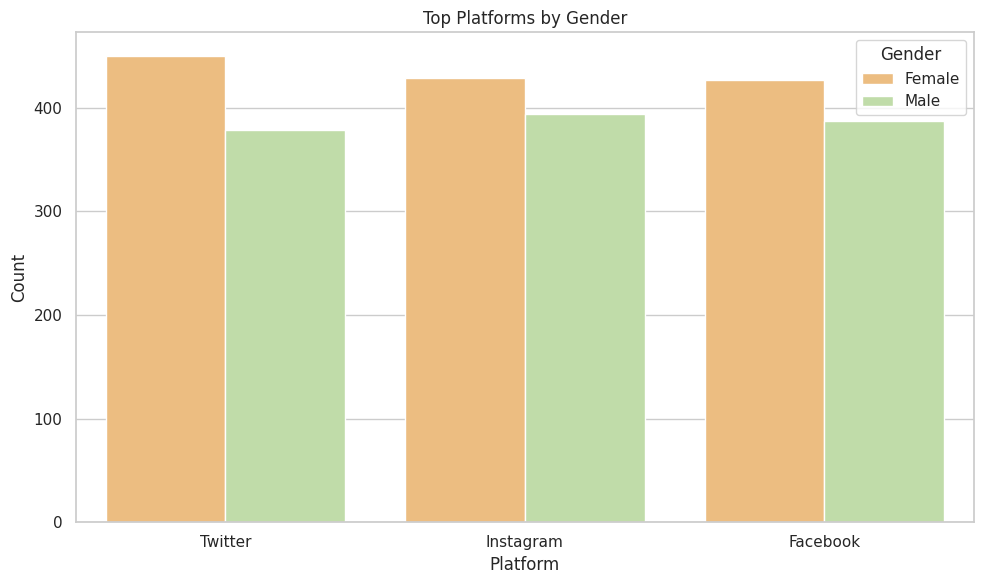

In [16]:
#Gender vs Platform
if {"Gender", "Platform"}.issubset(df.columns):
    df_gp2 = df[
        ~df["Gender"].isin(["Unknown", "unknown", "Prefer not to say", np.nan])
        & ~df["Platform"].isin(["Unknown", "unknown", "UNKNOWN", np.nan])
    ]

    top_platforms = df_gp2["Platform"].value_counts().head(8).index
    df_gp2 = df_gp2[df_gp2["Platform"].isin(top_platforms)]

    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df_gp2,
        x="Platform",
        hue="Gender",
        order=top_platforms,
        palette="Spectral"
    )
    plt.title("Top Platforms by Gender")
    plt.xlabel("Platform")
    plt.ylabel("Count")
    plt.legend(title="Gender")
    plt.tight_layout()
    plt.show()


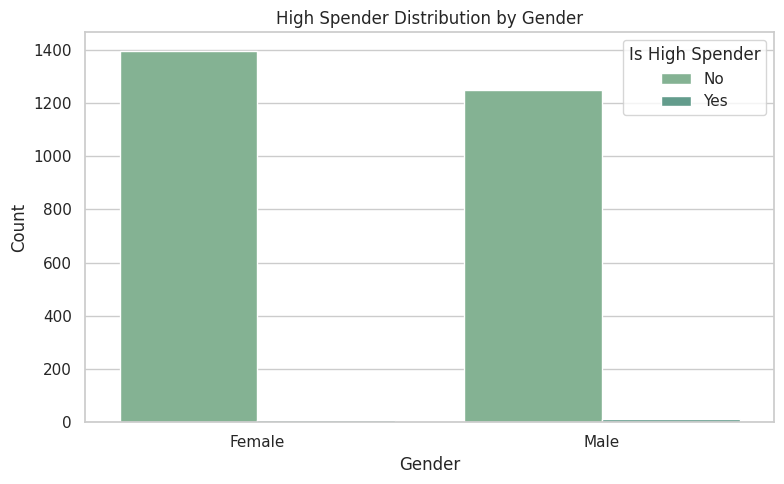

In [25]:
#Gender vs High Spender
df = df.rename(columns=lambda c: c.strip().replace("\t", ""))

# Try to resolve the high-spender column case-insensitively
candidate_cols = [c for c in df.columns if c.lower().replace("_","") in {"ishighspender", "ishighspend", "highspender"}]
if len(candidate_cols) == 0 and "IsHighSpender" in df.columns:
    candidate_cols = ["IsHighSpender"]  # fallback if exact name exists

if "Gender" in df.columns and len(candidate_cols) > 0:
    hs_col = candidate_cols[0]  # pick the first match
    tmp = df.copy()

    # Coerce common representations of binary to 0/1
    mapping = {
        True: 1, False: 0,
        "yes": 1, "no": 0, "Yes": 1, "No": 0,
        "Y": 1, "N": 0, "y": 1, "n": 0,
        "High": 1, "Low": 0, "HIGH": 1, "LOW": 0,
        "1": 1, "0": 0
    }
    tmp["isHighSpender_bin"] = tmp[hs_col].replace(mapping)
    tmp["isHighSpender_bin"] = pd.to_numeric(tmp["isHighSpender_bin"], errors="coerce")

    # Clean Gender
    bad_genders = {"Unknown", "unknown", "UNKNOWN", "Prefer not to say", None, np.nan}
    tmp = tmp[~tmp["Gender"].isin(bad_genders)].dropna(subset=["Gender"])

    # Keep only 0/1
    tmp = tmp[tmp["isHighSpender_bin"].isin([0, 1])]

    # Diagnostics if nothing to plot
    if tmp.empty:
        print("No rows to plot after cleaning/coercion.")
        print("\nDistinct original high-spender values (first 20):")
        print(df[hs_col].value_counts(dropna=False).head(20))
        print("\nDistinct Gender values (first 20):")
        print(df["Gender"].value_counts(dropna=False).head(20))
    else:
        gender_order = tmp["Gender"].value_counts().index

        plt.figure(figsize=(8, 5))
        sns.countplot(
            data=tmp,
            x="Gender",
            hue="isHighSpender_bin",
            order=gender_order,
            hue_order=[0, 1]
        )
        plt.title("High Spender Distribution by Gender")
        plt.xlabel("Gender")
        plt.ylabel("Count")
        handles, _ = plt.gca().get_legend_handles_labels()
        plt.legend(handles=handles, labels=["No", "Yes"], title="Is High Spender")
        plt.tight_layout()
        plt.show()
else:
    missing = []
    if "Gender" not in df.columns:
        missing.append("Gender")
    if len([c for c in df.columns if c.lower().replace("_","") in {"ishighspender","ishighspend","highspender"}]) == 0 and "IsHighSpender" not in df.columns:
        missing.append("IsHighSpender (any case/spacing)")
    print(f"Missing required column(s): {set(missing)}")

## Transaction & Spending Behavior - Visualization

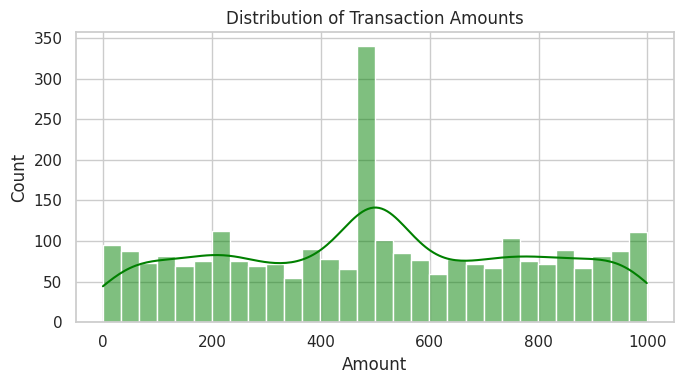

In [8]:
# spending behavior
if "Amount" in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df["Amount"], bins=30, kde=True, color="green")
    plt.title("Distribution of Transaction Amounts")
    plt.xlabel("Amount")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

####
- Insight:	The distribution is right-skewed, indicating that the majority of purchases are small-to-mid range, but a "long tail" of high-value transactions contributes significantly to the overall revenue pool.
- Recommendatio:	Value-Based Loyalty Programs: Introduce tiered loyalty rewards that incentivize both high-frequency, small-volume purchases (to boost transaction count) and occasional, high-ticket purchases (to capture high-margin revenue). Focus on upselling and bundling strategies for the high volume of mid-range purchases to increase Average Order Value (AOV).

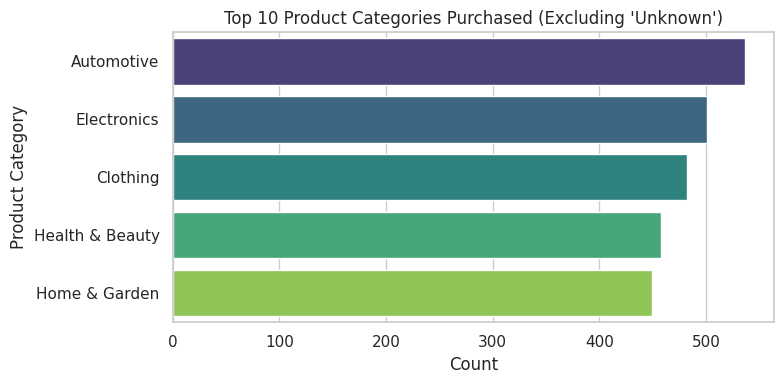

In [10]:
if "ProductCategory" in df.columns:

    df_filtered = df[~df["ProductCategory"].isin(["Unknown", "unknown", "UNKNOWN"])].dropna(subset=["ProductCategory"])

    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df_filtered,
        y="ProductCategory",
        order=df_filtered["ProductCategory"].value_counts().head(10).index,
        palette="viridis"
    )
    plt.title("Top 10 Product Categories Purchased (Excluding 'Unknown')")
    plt.ylabel("Product Category")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()


####

- Insight: Automotive and Electronics are the most frequent product categories by transaction count. This highlights these categories as the company's core product strengths and primary revenue streams.
- Recommendation: Core Strategy & Cross-Selling: Dedicate the largest inventory and marketing budgets to the Automotive and Electronics categories. Develop cross-selling models that link purchases in these two areas (e.g., recommending electronic gadgets relevant to automotive upgrades) to increase cart size and purchase diversity.


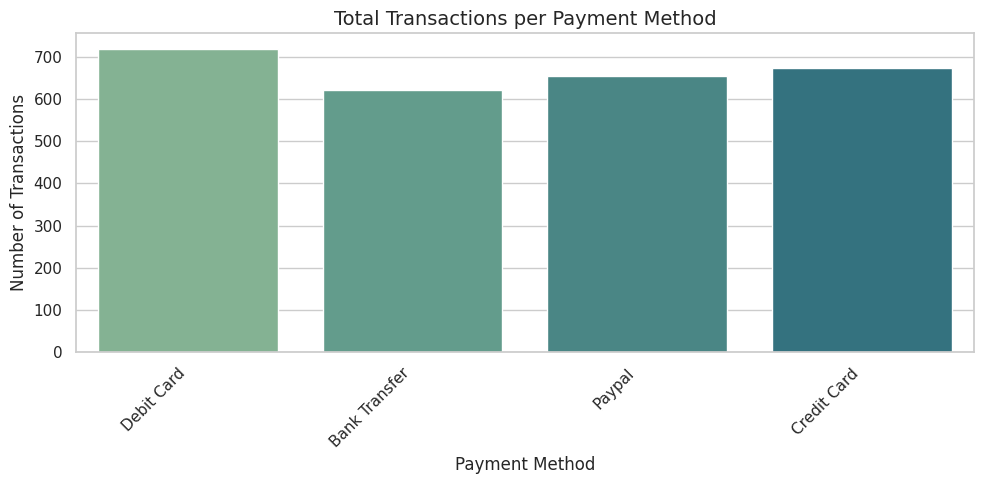

In [26]:
if "PaymentMethod" in df.columns:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(
        data=df,
        x="PaymentMethod",
        palette=custom_palette
    )
    ax.set_title("Total Transactions per Payment Method", fontsize=14)
    ax.set_xlabel("Payment Method")
    ax.set_ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


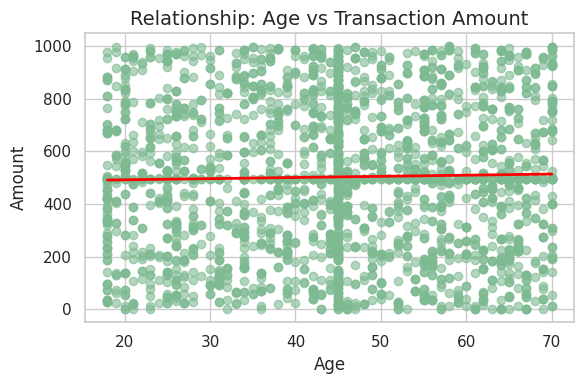

In [70]:
if "Age" in df.columns and "Amount" in df.columns:
    plt.figure(figsize=(6, 4))

    # Use regplot to include a fitted regression line
    ax = sns.regplot(
        data=df,
        x="Age",
        y="Amount",
        scatter_kws={'alpha':0.6},
        line_kws={'color':'red', 'lw':2},
        ci=None
    )

    ax.set_title("Relationship: Age vs Transaction Amount", fontsize=14)
    ax.set_xlabel("Age")
    ax.set_ylabel("Amount")
    plt.tight_layout()
    plt.show()

## Time Series Trends - Visualization

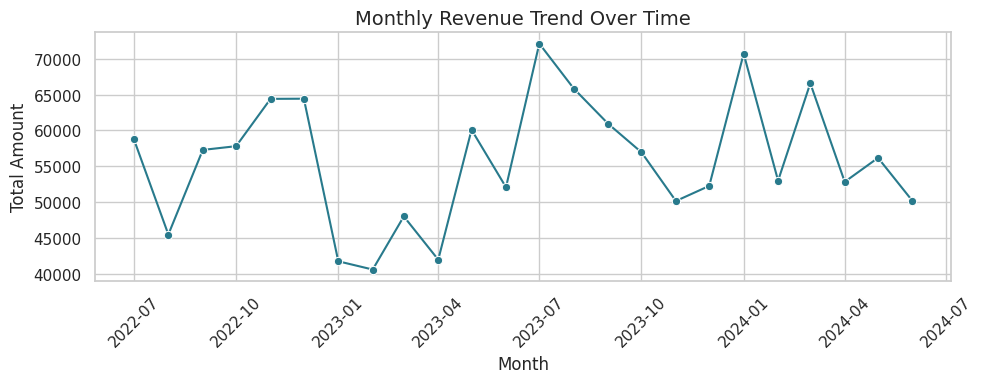

In [27]:
if "TransactionDate" in df.columns and "Amount" in df.columns:
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")

    # Drop rows without a valid date
    monthly_df = df.dropna(subset=["TransactionDate"]).copy()

    # Extract monthly period safely
    monthly_df["Month"] = monthly_df["TransactionDate"].dt.to_period("M").dt.to_timestamp()

    # Group by month
    monthly = monthly_df.groupby("Month", as_index=False)["Amount"].sum()

    if not monthly.empty:
        plt.figure(figsize=(10, 4))
        sns.lineplot(data=monthly, x="Month", y="Amount", marker="o", color=custom_palette[3])
        plt.title("Monthly Revenue Trend Over Time", fontsize=14)
        plt.xlabel("Month")
        plt.ylabel("Total Amount")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid transaction dates to plot.")


####
- Insight:	The data shows an overall upward trend in transaction volume and value, suggesting a healthy business growth trajectory. Distinct peaks and dips indicate potential seasonality, holiday effects, or campaign-specific successes/failures that need detailed investigation.
- Recommendation:	Demand Forecasting and Optimization: Implement advanced time-series forecasting to predict future demand based on identified seasonal/cyclical patterns. Use historical peak data to strategically schedule marketing campaigns and inventory procurement to capitalize on known high-spending periods.

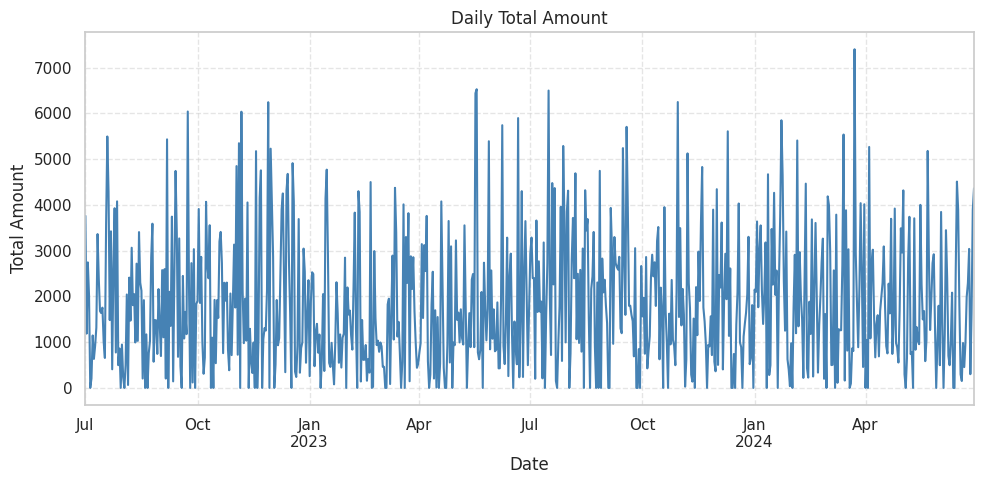

In [28]:
# Daily Transaction
DATE_COL = "TransactionDate"
AMOUNT_COL = "Amount"

df_ts = df.copy()
df_ts[DATE_COL] = pd.to_datetime(df_ts[DATE_COL], errors="coerce")
df_ts = df_ts.dropna(subset=[DATE_COL])
df_ts = df_ts.sort_values(DATE_COL).set_index(DATE_COL)

daily_amount = df_ts[AMOUNT_COL].resample("D").sum()

plt.figure(figsize=(10,5))
daily_amount.plot(color="steelblue")
plt.title("Daily Total Amount")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



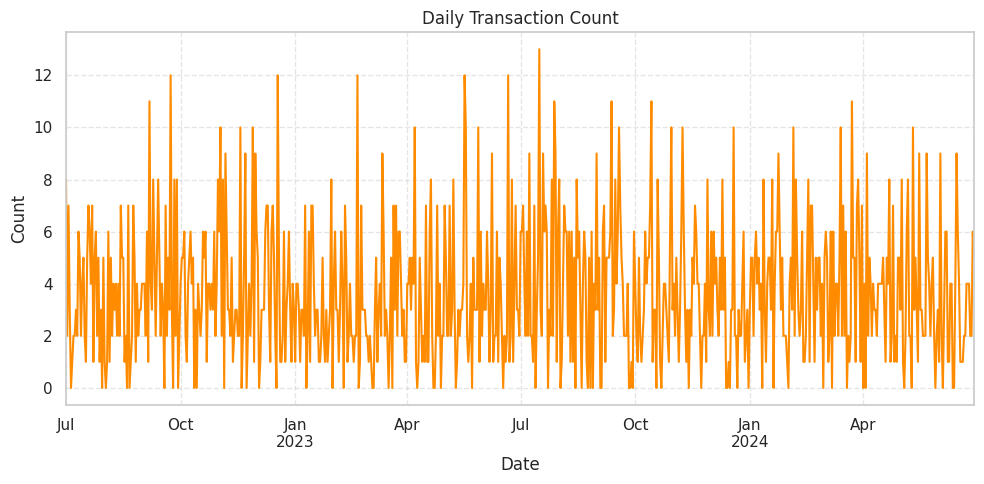

In [29]:
# Daily Transaction Count
daily_count = df_ts[AMOUNT_COL].resample("D").count()

plt.figure(figsize=(10,5))
daily_count.plot(color="darkorange")
plt.title("Daily Transaction Count")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

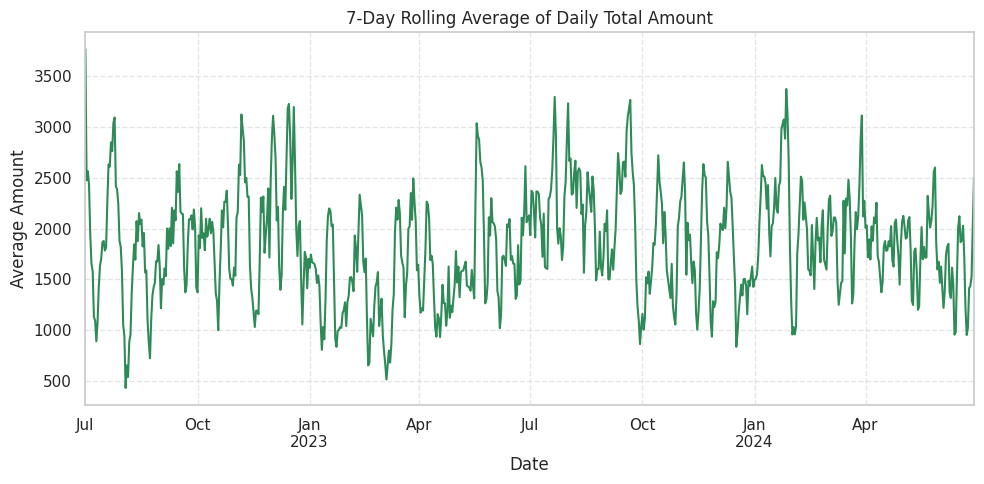

In [30]:
# 7-Day Rolling Mean of Daily Amount
rolling_mean = daily_amount.rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(10,5))
rolling_mean.plot(color="seagreen")
plt.title("7-Day Rolling Average of Daily Total Amount")
plt.xlabel("Date")
plt.ylabel("Average Amount")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

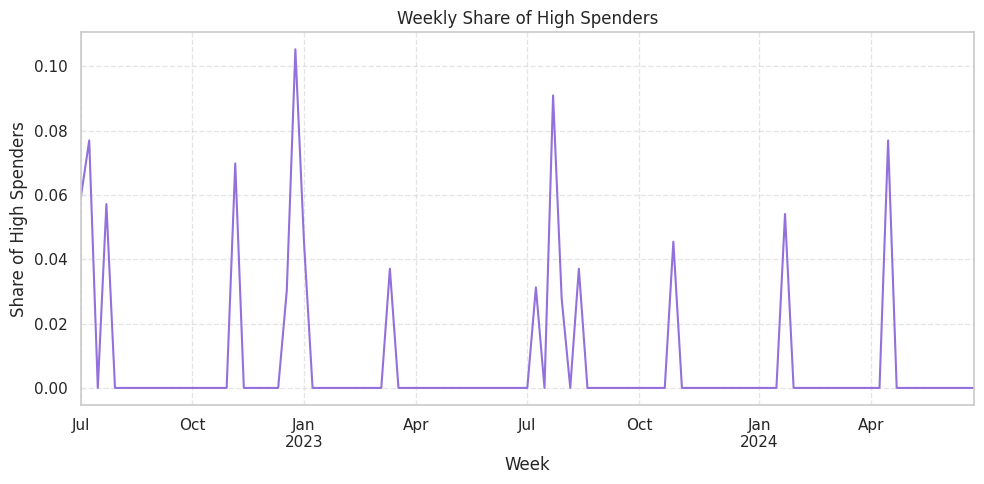

In [31]:
# Weekly Share of High Spenders
if "IsHighSpender" in df_ts.columns:
    weekly_share_high = df_ts["IsHighSpender"].resample("W").mean()

    plt.figure(figsize=(10,5))
    weekly_share_high.plot(color="mediumpurple")
    plt.title("Weekly Share of High Spenders")
    plt.xlabel("Week")
    plt.ylabel("Share of High Spenders")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

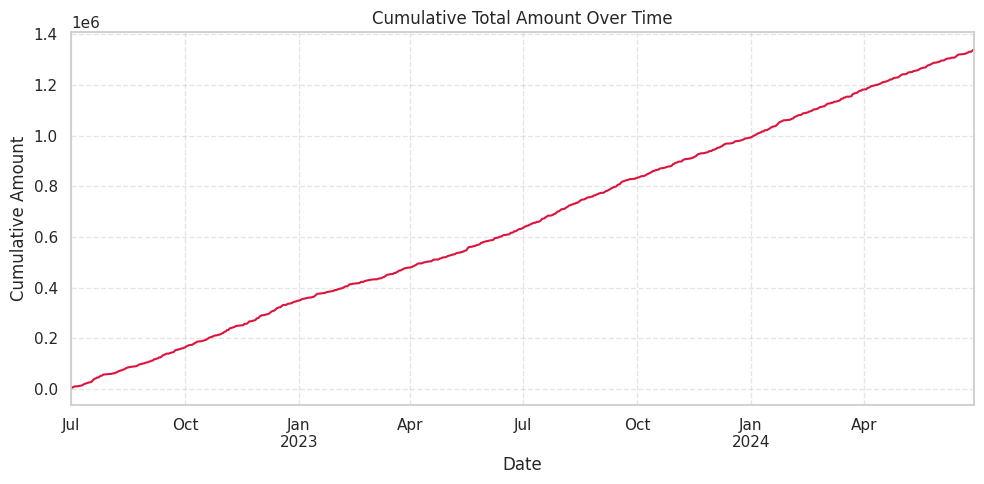

In [32]:
# Cumulative Revenue Over Time
cumulative_amount = daily_amount.cumsum()

plt.figure(figsize=(10,5))
cumulative_amount.plot(color="crimson")
plt.title("Cumulative Total Amount Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Amount")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

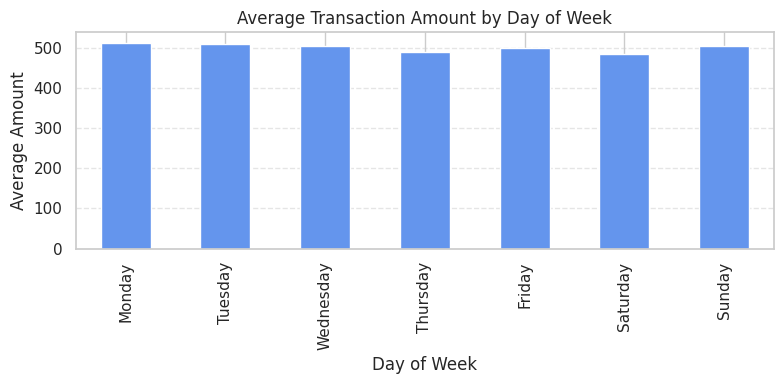

In [33]:
# Average Transaction Amount by Day of Week
df_ts["DayOfWeek"] = df_ts.index.day_name()
avg_by_day = df_ts.groupby("DayOfWeek")[AMOUNT_COL].mean()
# Reorder for logical weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_day = avg_by_day.reindex(weekday_order)

plt.figure(figsize=(8,4))
avg_by_day.plot(kind="bar", color="cornflowerblue")
plt.title("Average Transaction Amount by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Amount")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Engagement & Interactions - Visualization

In [34]:
INT_DATE_COL = "InteractionDate"
PLATFORM_COL = "Platform"
ITYPE_COL = "InteractionType"
SENT_COL = "Sentiment"
USER_COL = "CustomerID"

df_eng = df.copy()
df_eng[INT_DATE_COL] = pd.to_datetime(df_eng[INT_DATE_COL], errors="coerce")
df_eng = df_eng.dropna(subset=[INT_DATE_COL]).sort_values(INT_DATE_COL).set_index(INT_DATE_COL)

def clean_unknown(series):
    return series.replace({"Unknown":"", "unknown":"", "UNKNOWN":"", "Prefer not to say":""}).replace("", np.nan)

for c in [PLATFORM_COL, ITYPE_COL, SENT_COL]:
    if c in df_eng.columns:
        df_eng[c] = clean_unknown(df_eng[c])

# a small helper for nicer plots
def finish(ax, title, xlab, ylab):
    ax.set_title(title)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

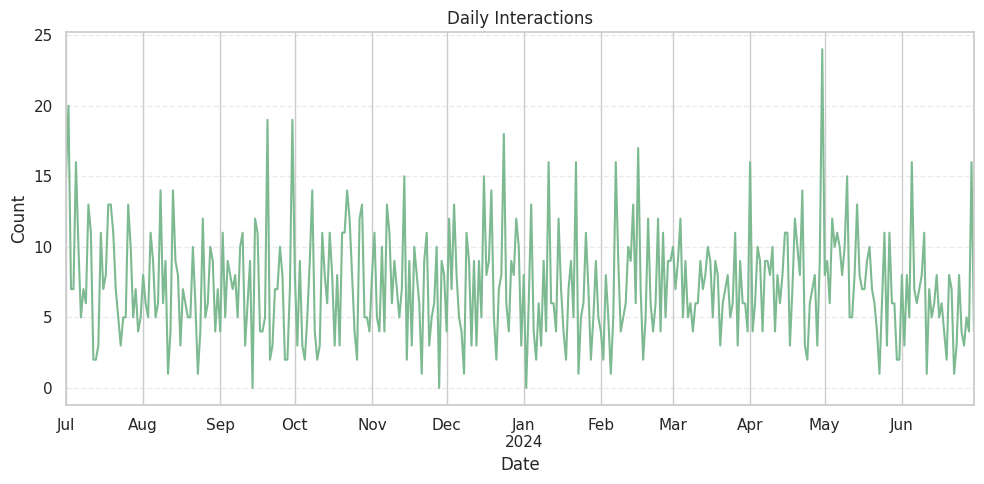

In [35]:
# Daily Interaction
daily_interactions = df_eng.resample("D")[USER_COL].count()

plt.figure(figsize=(10,5))
ax = daily_interactions.plot()
finish(ax, "Daily Interactions", "Date", "Count")
plt.show()


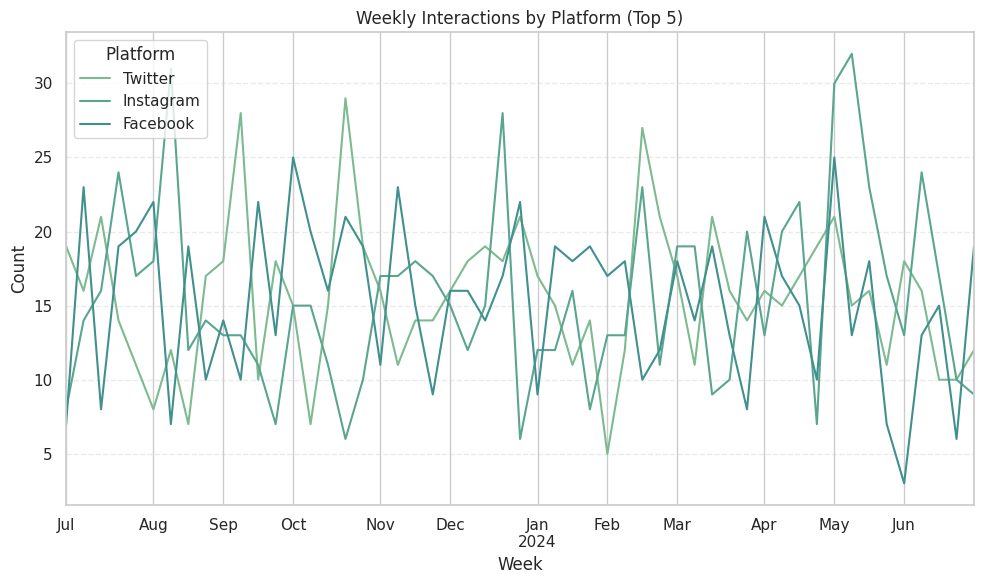

In [37]:
# Weekly Interactions by Platform (Top 5)", "Week", "Count
if PLATFORM_COL in df_eng.columns:
    top_platforms = (
        df_eng[PLATFORM_COL]
        .dropna()
        .value_counts()
        .head(5)
        .index
    )
    plt.figure(figsize=(10,6))
    for p in top_platforms:
        series = df_eng[df_eng[PLATFORM_COL]==p].resample("W")[USER_COL].count()
        ax = series.plot(label=p)
    plt.legend(title="Platform")
    finish(ax, "Weekly Interactions by Platform (Top 5)", "Week", "Count")
    plt.show()


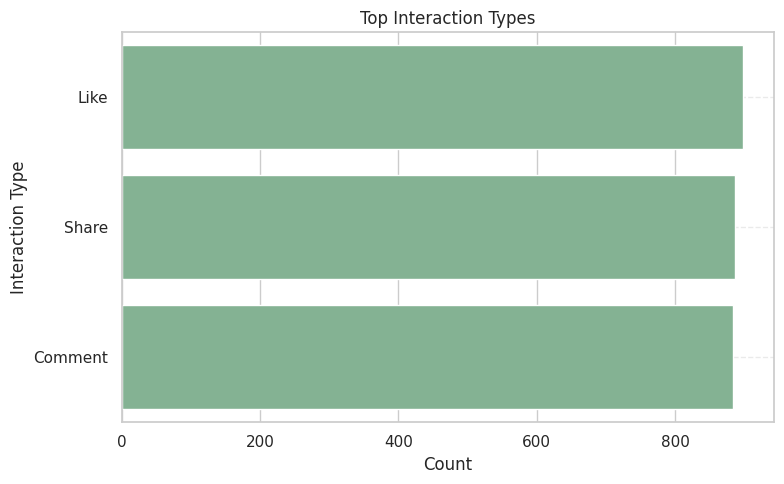

In [38]:
if ITYPE_COL in df_eng.columns:
    itype_counts = df_eng[ITYPE_COL].dropna().value_counts().head(12)
    plt.figure(figsize=(8,5))
    ax = sns.barplot(x=itype_counts.values, y=itype_counts.index)
    finish(ax, "Top Interaction Types", "Count", "Interaction Type")
    plt.show()

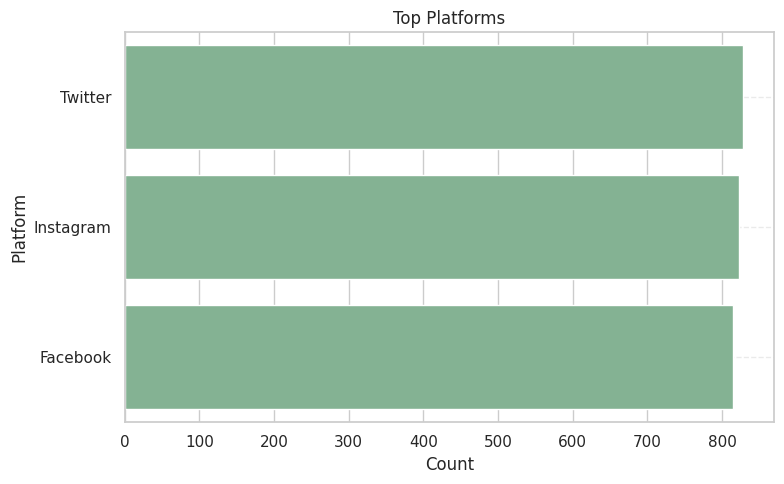

In [39]:
if PLATFORM_COL in df_eng.columns:
    plat_counts = df_eng[PLATFORM_COL].dropna().value_counts().head(12)
    plt.figure(figsize=(8,5))
    ax = sns.barplot(x=plat_counts.values, y=plat_counts.index)
    finish(ax, "Top Platforms", "Count", "Platform")
    plt.show()


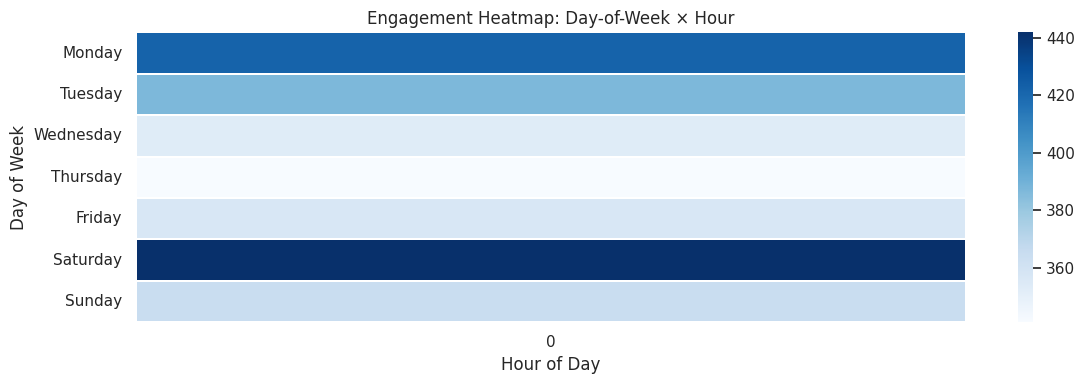

In [58]:
df_heat = df_eng.copy()
df_heat["dow"] = df_heat.index.day_name()
df_heat["hour"] = df_heat.index.hour

order_dow = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = (df_heat
         .groupby(["dow","hour"])[USER_COL]
         .count()
         .reset_index()
         .pivot(index="dow", columns="hour", values=USER_COL)
         .reindex(order_dow))

plt.figure(figsize=(12,4))
ax = sns.heatmap(pivot, cmap="Blues", linewidths=0.3, linecolor="white")
finish(ax, "Engagement Heatmap: Day-of-Week × Hour", "Hour of Day", "Day of Week")
plt.show()


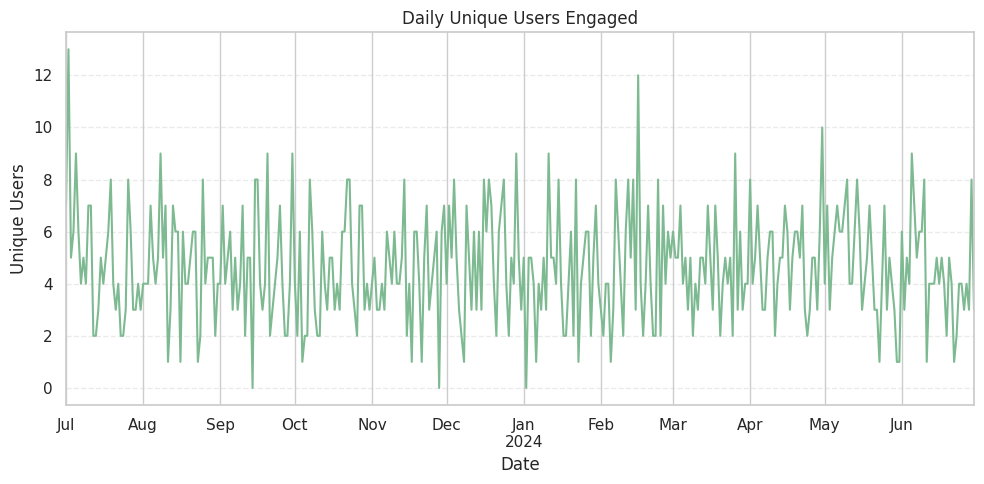

In [60]:
daily_unique_users = df_eng.resample("D")[USER_COL].nunique()

plt.figure(figsize=(10,5))
ax = daily_unique_users.plot()
finish(ax, "Daily Unique Users Engaged", "Date", "Unique Users")
plt.show()


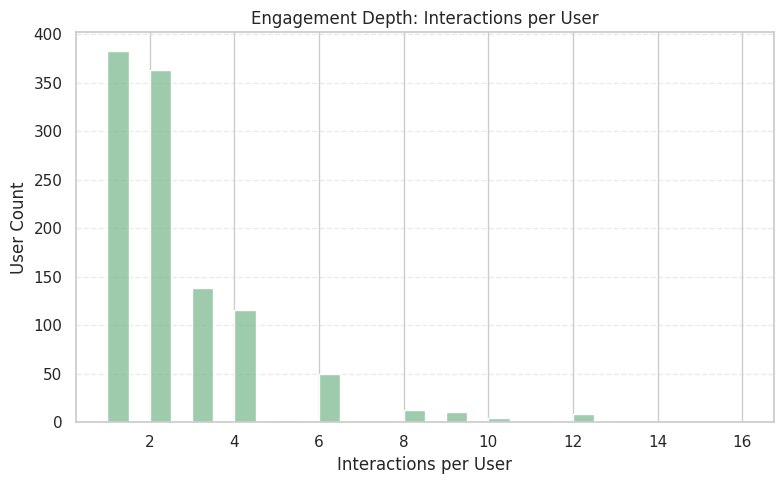

In [61]:
per_user = df_eng.groupby(USER_COL)[USER_COL].count().rename("interactions_per_user")

plt.figure(figsize=(8,5))
ax = sns.histplot(per_user, bins=30)
finish(ax, "Engagement Depth: Interactions per User", "Interactions per User", "User Count")
plt.show()


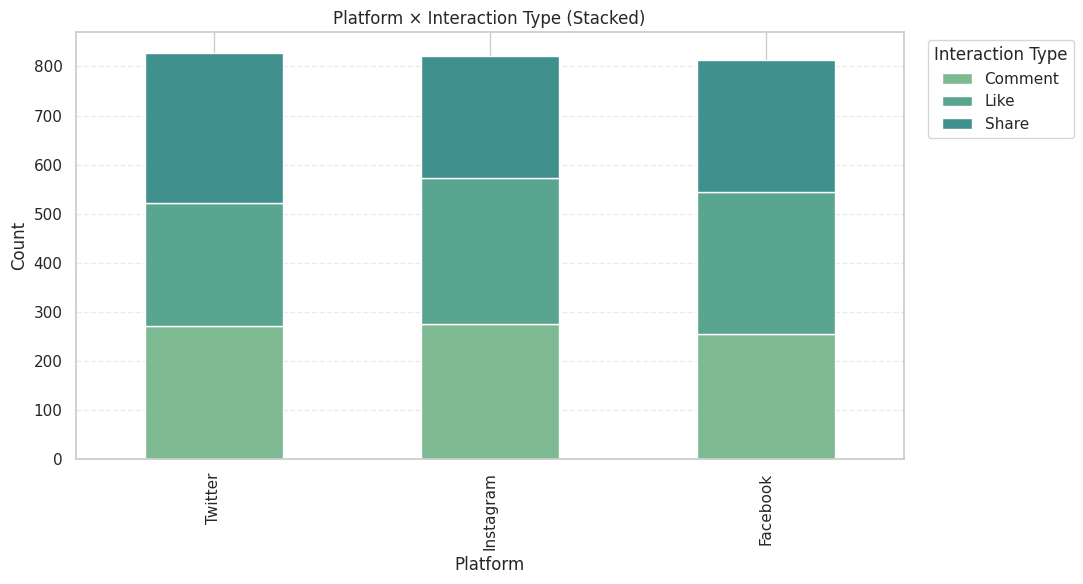

In [62]:
if {PLATFORM_COL, ITYPE_COL}.issubset(df_eng.columns):
    df_pit = df_eng.dropna(subset=[PLATFORM_COL, ITYPE_COL])
    top_plats = df_pit[PLATFORM_COL].value_counts().head(6).index
    df_pit = df_pit[df_pit[PLATFORM_COL].isin(top_plats)]

    cross = df_pit.groupby([PLATFORM_COL, ITYPE_COL])[USER_COL].count().unstack(fill_value=0)
    cross = cross.loc[top_plats]  # keep order

    ax = cross.plot(kind="bar", stacked=True, figsize=(11,6))
    plt.legend(title="Interaction Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    finish(ax, "Platform × Interaction Type (Stacked)", "Platform", "Count")
    plt.show()


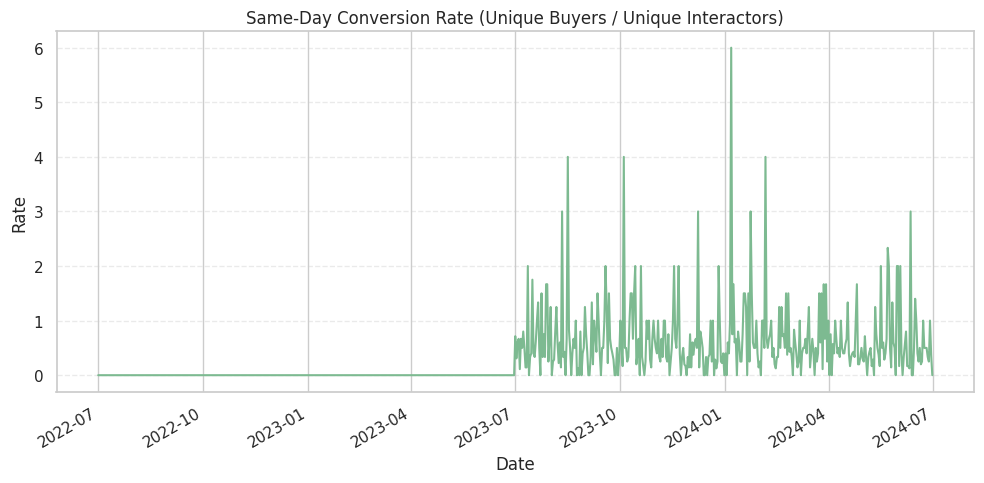

In [64]:
# prep interactions (date only)
inter = (
    df.copy()[[USER_COL, "InteractionDate"]]
    .assign(InteractionDate=lambda d: pd.to_datetime(d["InteractionDate"], errors="coerce"))
    .dropna(subset=["InteractionDate"])
)
inter["date"] = inter["InteractionDate"].dt.normalize()

# prep transactions (date only)
txn = (
    df.copy()[[USER_COL, "TransactionDate"]]
    .assign(TransactionDate=lambda d: pd.to_datetime(d["TransactionDate"], errors="coerce"))
    .dropna(subset=["TransactionDate"])
)
txn["date"] = txn["TransactionDate"].dt.normalize()

# same-day user/date presence
daily_inter_users = inter.groupby("date")[USER_COL].nunique().rename("unique_interactors")
daily_buy_users   = txn.groupby("date")[USER_COL].nunique().rename("unique_buyers")

conv = pd.concat([daily_inter_users, daily_buy_users], axis=1).fillna(0.0)
conv["same_day_conv_rate"] = (conv["unique_buyers"] / conv["unique_interactors"]).replace([np.inf, np.nan], 0)

plt.figure(figsize=(10,5))
ax = conv["same_day_conv_rate"].plot()
finish(ax, "Same-Day Conversion Rate (Unique Buyers / Unique Interactors)", "Date", "Rate")
plt.show()


####

- Technical: Strong dominance indicates channel concentration risk; consider adding entropy metrics of platform usage.
- Business: Double down on dominant platforms for paid/organic; test new formats on runner-ups to diversify reach.

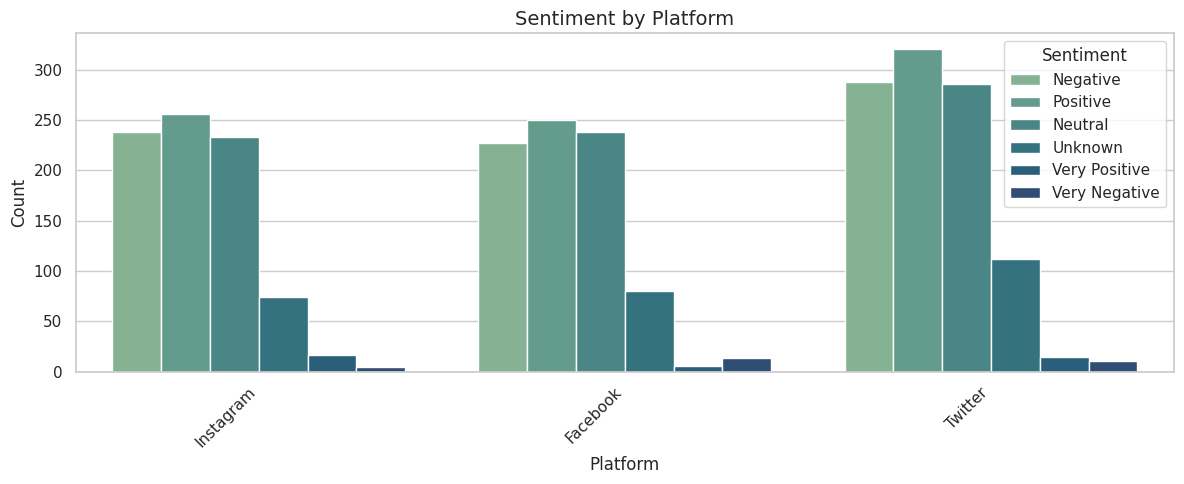

In [ ]:
if "Platform" in df.columns and "Sentiment" in df.columns:
    plt.figure(figsize=(12, 5))
    ax = sns.countplot(data=df, x="Platform", hue="Sentiment")
    ax.set_title("Sentiment by Platform", fontsize=14)
    ax.set_xlabel("Platform"); ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

####

- Insight:	Overall customer sentiment is positive. While Twitter and Facebook drive the highest volume of interactions, Instagram exhibits a significant proportion of negative interactions relative to its total volume.
- Recommendation:	Proactive Customer Service: Reallocate social media customer support and monitoring resources to heavily prioritize interactions on Instagram to rapidly address and resolve negative feedback, mitigating potential public relations risks. Maintain engagement levels on Twitter and Facebook, focusing on converting positive interactions into brand advocacy (e.g., user-generated content features).




## Correlations & Relationships - Visualization

In [65]:
from scipy.stats import chi2_contingency

maybe_cats = [
    "Gender","Location","IncomeLevel","ProductCategory","PaymentMethod",
    "Platform","InteractionType","Sentiment","IsHighSpender"
]
maybe_cats = [c for c in maybe_cats if c in df.columns]
auto_cats = [c for c in df.columns if df[c].dtype.name in ["object","category"]]
cat_cols = list(dict.fromkeys(maybe_cats + auto_cats))  # de-dup, keep order
UNKNOWN_TOKENS = {"Unknown","unknown","UNKNOWN","Prefer not to say",""}
df_clean = df.copy()
for c in cat_cols:
    df_clean[c] = (
        df_clean[c]
        .replace({u: np.nan for u in UNKNOWN_TOKENS})
        .astype("category")
    )

def cramers_v(x, y):
    tbl = pd.crosstab(x, y)
    if tbl.size == 0 or tbl.to_numpy().sum() == 0:
        return np.nan
    chi2, _, _, _ = chi2_contingency(tbl)
    n = tbl.to_numpy().sum()
    phi2 = chi2 / n
    r, k = tbl.shape
    # bias correction
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2_corr / denom)

def association_matrix(df_cat, columns):
    cols = [c for c in columns if c in df_cat.columns]
    m = pd.DataFrame(index=cols, columns=cols, dtype=float)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if j < i:
                m.loc[c1, c2] = m.loc[c2, c1]  # symmetry
            else:
                v = 1.0 if c1 == c2 else cramers_v(df_cat[c1], df_cat[c2])
                m.loc[c1, c2] = v
    return m.astype(float)

cramers_mat = association_matrix(df_clean, cat_cols)
cramers_mat


,Gender,Location,IncomeLevel,ProductCategory,PaymentMethod,Platform,InteractionType,Sentiment,IsHighSpender,CustomerID,TransactionID,InteractionID
Gender,1.000000,0.756463,0.044502,0.048537,0.060757,0.000000,0.000000,0.046398,0.008751,0.769250,0.601125,0.602683
Location,0.756463,1.000000,0.762186,0.480351,0.464782,0.462904,0.477794,0.454794,0.402291,0.986639,0.783716,0.784869
IncomeLevel,0.044502,0.762186,1.000000,0.000000,0.055759,0.023689,0.033642,0.044908,0.000000,0.771529,0.602529,0.607261
ProductCategory,0.048537,0.480351,0.000000,1.000000,0.026696,0.000000,0.005807,0.000000,0.036973,0.487710,0.603116,0.050181
PaymentMethod,0.060757,0.464782,0.055759,0.026696,1.000000,0.000000,0.004708,0.017168,0.048848,0.473337,0.601350,0.000000
Platform,0.000000,0.462904,0.023689,0.000000,0.000000,1.000000,0.039003,0.021045,0.000000,0.473782,0.000000,0.607417
InteractionType,0.000000,0.477794,0.033642,0.005807,0.004708,0.039003,1.000000,0.067846,0.000000,0.486358,0.077870,0.602796
Sentiment,0.046398,0.454794,0.044908,0.000000,0.017168,0.021045,0.067846,1.000000,0.020604,0.464132,0.000000,0.592485
IsHighSpender,0.008751,0.402291,0.000000,0.036973,0.048848,0.000000,0.000000,0.020604,1.000000,0.381711,0.601125,0.000000
CustomerID,0.769250,0.986639,0.771529,0.487710,0.473337,0.473782,0.486358,0.464132,0.381711,1.000000,0.799662,0.800839


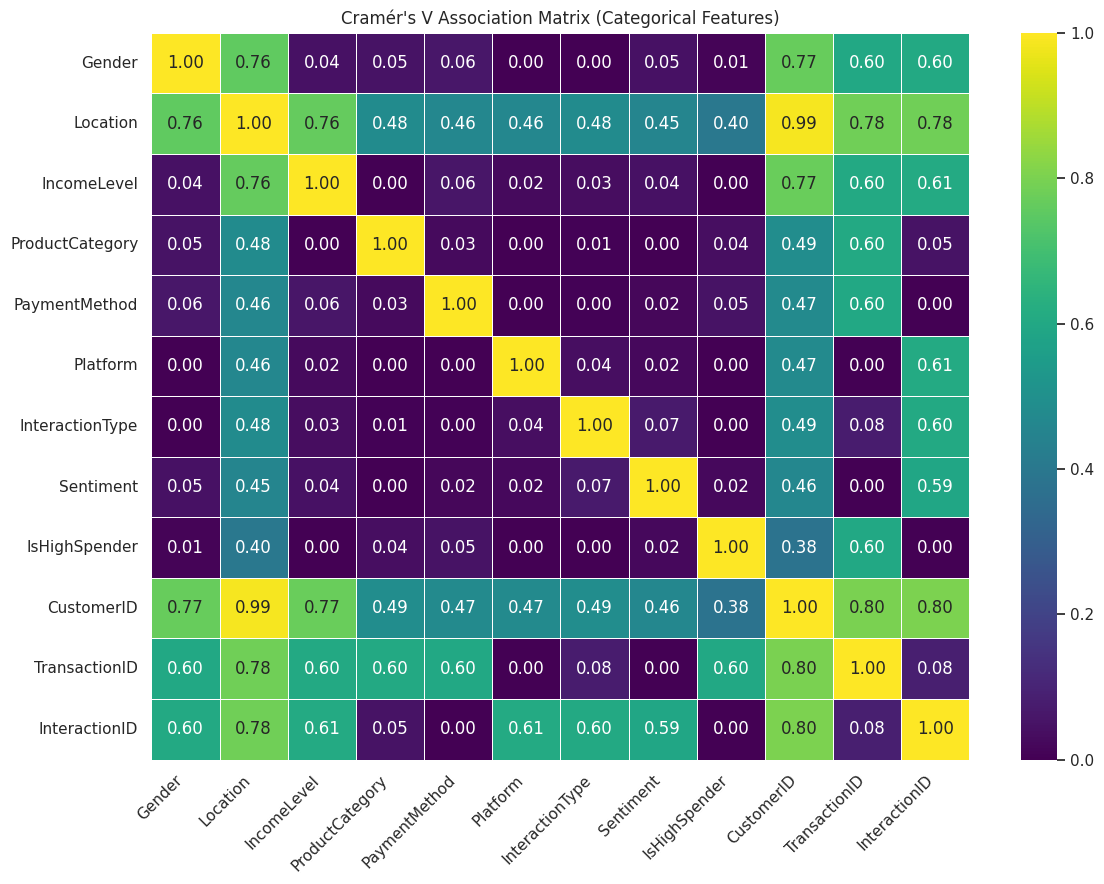

In [66]:
plt.figure(figsize=(12, 9))
ax = sns.heatmap(
    cramers_mat,
    vmin=0, vmax=1, cmap="viridis",
    annot=True, fmt=".2f", linewidths=0.5, linecolor="white"
)
plt.title("Cramér's V Association Matrix (Categorical Features)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


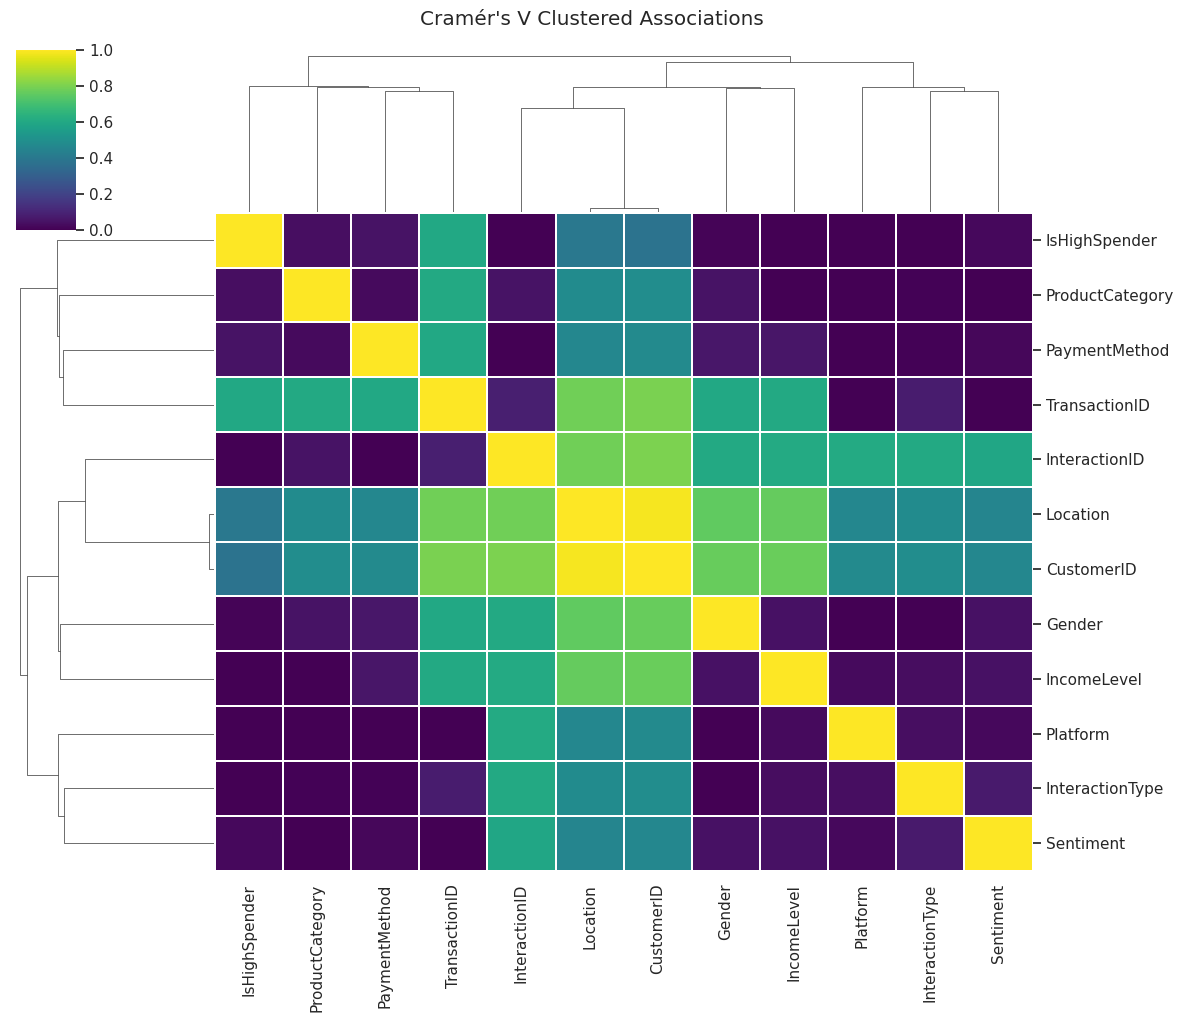

In [67]:
# rows/cols clustered by similarity
sns.clustermap(
    cramers_mat.fillna(0),
    cmap="viridis", vmin=0, vmax=1,
    linewidths=0.3, figsize=(12, 10)
)
plt.suptitle("Cramér's V Clustered Associations", y=1.02)
plt.show()


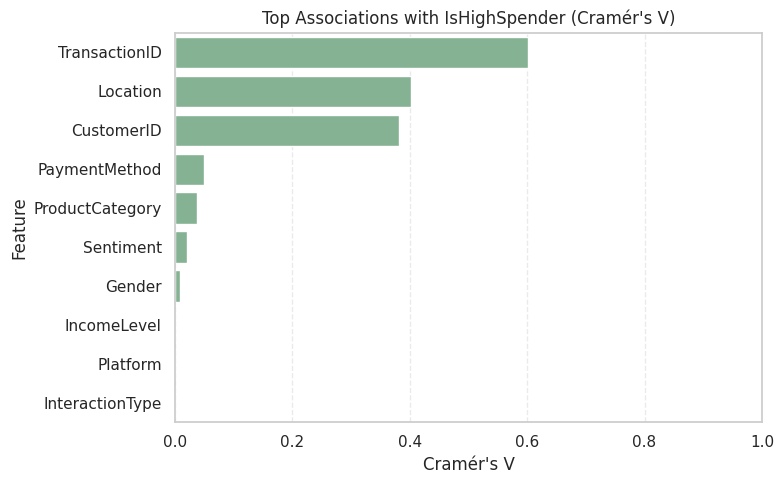

In [68]:
target = "IsHighSpender"
if target in cramers_mat.columns:
    top_assocs = (
        cramers_mat[target]
        .drop(labels=[target])
        .sort_values(ascending=False)
        .head(10)
    )
    plt.figure(figsize=(8,5))
    sns.barplot(x=top_assocs.values, y=top_assocs.index)
    plt.title(f"Top Associations with {target} (Cramér's V)")
    plt.xlabel("Cramér's V")
    plt.ylabel("Feature")
    plt.xlim(0, 1)
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


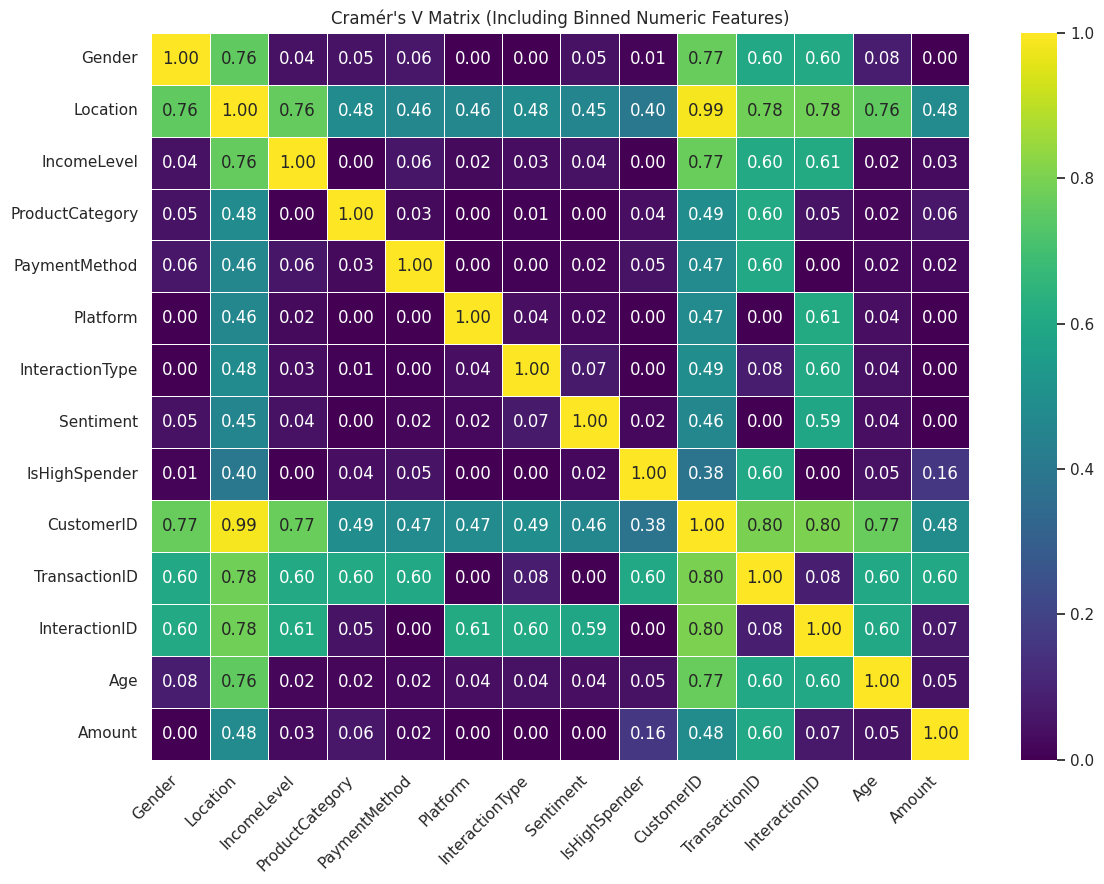

In [69]:
# choose numeric columns to bin (only those that exist)
num_to_bin = [c for c in ["Age","Amount"] if c in df_clean.columns]

df_binned = df_clean.copy()
for c in num_to_bin:
    try:
        # quartile bins; change q= to 5 or 10 if you prefer
        df_binned[c] = pd.qcut(df_binned[c], q=4, duplicates="drop").astype("category")
        cat_cols.append(c)  # include in categorical list
    except Exception:
        pass

cat_cols = list(dict.fromkeys(cat_cols))  # de-dup

cramers_mat_binned = association_matrix(df_binned, cat_cols)

plt.figure(figsize=(12, 9))
ax = sns.heatmap(
    cramers_mat_binned,
    vmin=0, vmax=1, cmap="viridis",
    annot=True, fmt=".2f", linewidths=0.5, linecolor="white"
)
plt.title("Cramér's V Matrix (Including Binned Numeric Features)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## High-spender Insights - Visualization

In [72]:
sns.set_theme()

DATE_COL = "TransactionDate"
AMOUNT_COL = "Amount"
HS_COL = "IsHighSpender"

CLEAN_TOKENS = {"Unknown","unknown","UNKNOWN","Prefer not to say",""}

df_hs = df.copy()
df_hs[DATE_COL] = pd.to_datetime(df_hs[DATE_COL], errors="coerce")
df_hs = df_hs.dropna(subset=[DATE_COL])
df_hs[AMOUNT_COL] = pd.to_numeric(df_hs[AMOUNT_COL], errors="coerce")
df_hs = df_hs.dropna(subset=[AMOUNT_COL, HS_COL])
for c in ["ProductCategory","Platform","IncomeLevel","Gender"]:
    if c in df_hs.columns:
        df_hs[c] = df_hs[c].replace({t: np.nan for t in CLEAN_TOKENS})
df_hs["HS_Label"] = df_hs[HS_COL].map({1:"High Spender", 0:"Not High Spender"})

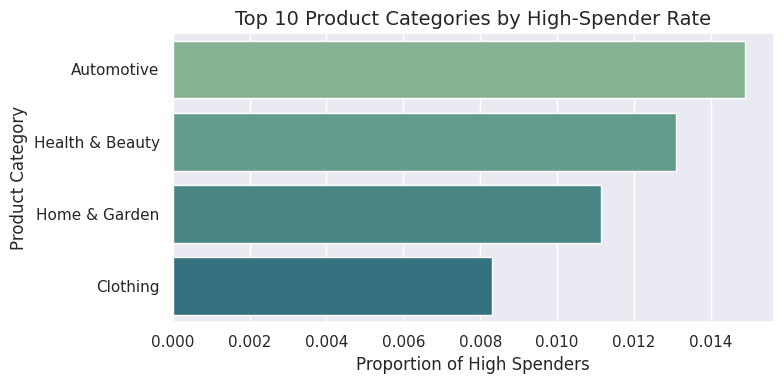

In [73]:
if "ProductCategory" in df.columns and "IsHighSpender" in df.columns:

    df_filtered = df[
        df["ProductCategory"].notna() &
        (df["ProductCategory"].str.lower() != "unknown")
    ]


    prop_cat = (
        df_filtered.groupby("ProductCategory")["IsHighSpender"]
        .mean()
        .reset_index()
    )


    prop_cat = prop_cat[prop_cat["IsHighSpender"] > 0]


    prop_cat = prop_cat.sort_values("IsHighSpender", ascending=False).head(10)

    # 5. Visualization
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(
        data=prop_cat,
        y="ProductCategory",
        x="IsHighSpender",
        palette=custom_palette
    )
    ax.set_title("Top 10 Product Categories by High-Spender Rate", fontsize=14)
    ax.set_xlabel("Proportion of High Spenders")
    ax.set_ylabel("Product Category")
    plt.tight_layout()
    plt.show()



####

- Technical: Rate stability matters; large variance suggests low event counts—use Wilson intervals or Beta-Binomial smoothing.
- Business: Rising rate indicates successful premium conversion; align CRM pushes with months showing lift.

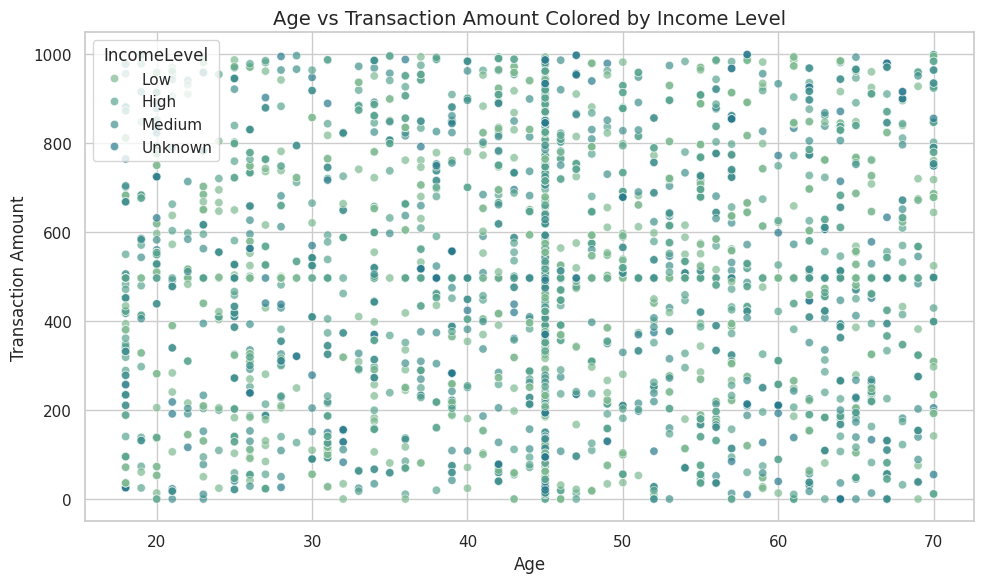

In [71]:
if "Age" in df.columns and "Amount" in df.columns and "IncomeLevel" in df.columns:
    plt.figure(figsize=(10, 6))
    ax = sns.scatterplot(
        data=df,
        x="Age",
        y="Amount",
        hue="IncomeLevel",
        palette=custom_palette,
        alpha=0.7
    )
    ax.set_title("Age vs Transaction Amount Colored by Income Level", fontsize=14)
    ax.set_xlabel("Age")
    ax.set_ylabel("Transaction Amount")
    plt.tight_layout()
    plt.show()


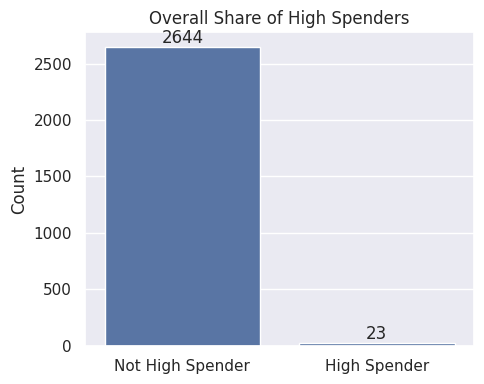

In [74]:
plt.figure(figsize=(5,4))
ax = sns.countplot(data=df_hs, x="HS_Label")
ax.set_title("Overall Share of High Spenders")
ax.set_xlabel("")
ax.set_ylabel("Count")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.show()


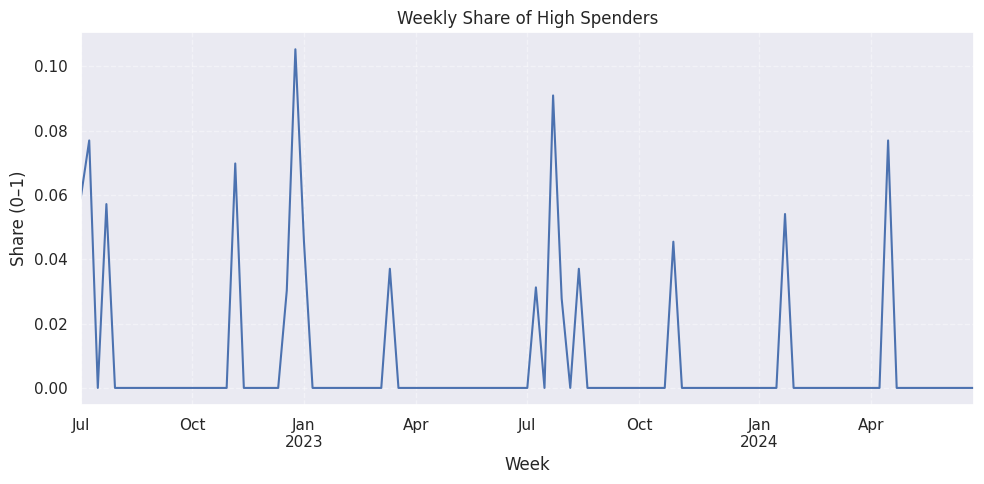

In [75]:
ts = df_hs.set_index(DATE_COL).sort_index()
weekly_share = ts[HS_COL].resample("W").mean()

plt.figure(figsize=(10,5))
ax = weekly_share.plot()
ax.set_title("Weekly Share of High Spenders")
ax.set_xlabel("Week"); ax.set_ylabel("Share (0–1)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


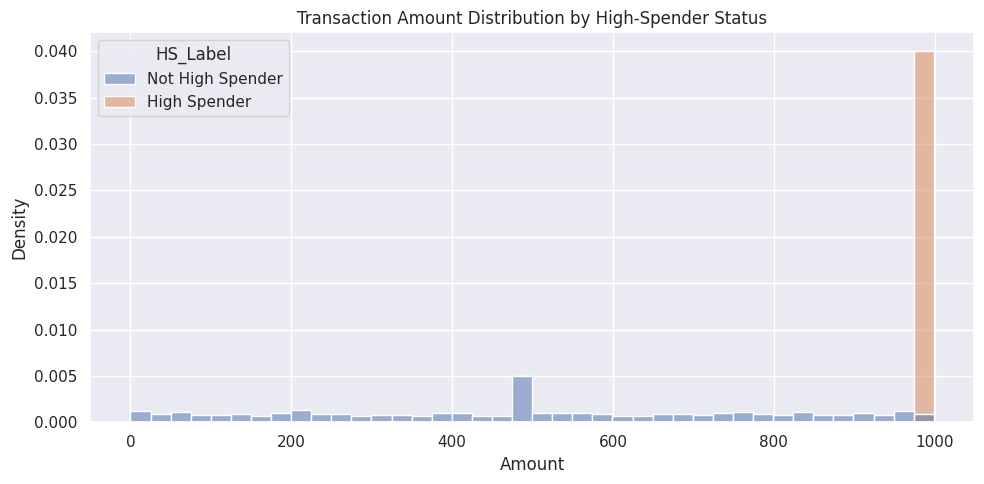

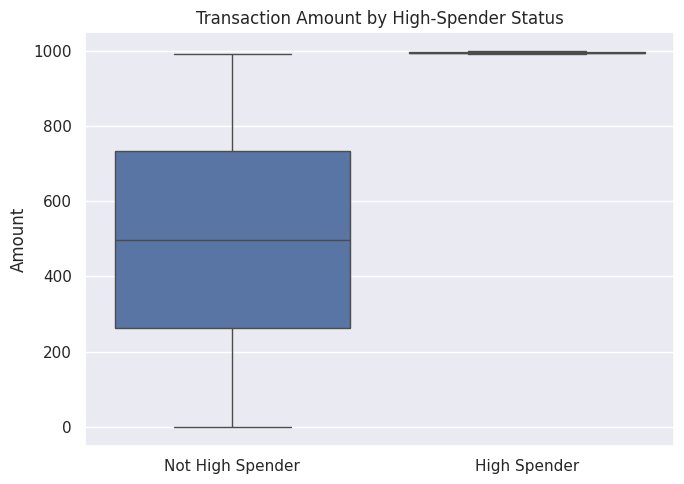

In [76]:
plt.figure(figsize=(10,5))
ax = sns.histplot(data=df_hs, x=AMOUNT_COL, hue="HS_Label", bins=40, stat="density", common_norm=False, alpha=0.5)
ax.set_title("Transaction Amount Distribution by High-Spender Status")
ax.set_xlabel("Amount"); ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
ax = sns.boxplot(data=df_hs, x="HS_Label", y=AMOUNT_COL)
ax.set_title("Transaction Amount by High-Spender Status")
ax.set_xlabel(""); ax.set_ylabel("Amount")
plt.tight_layout()
plt.show()


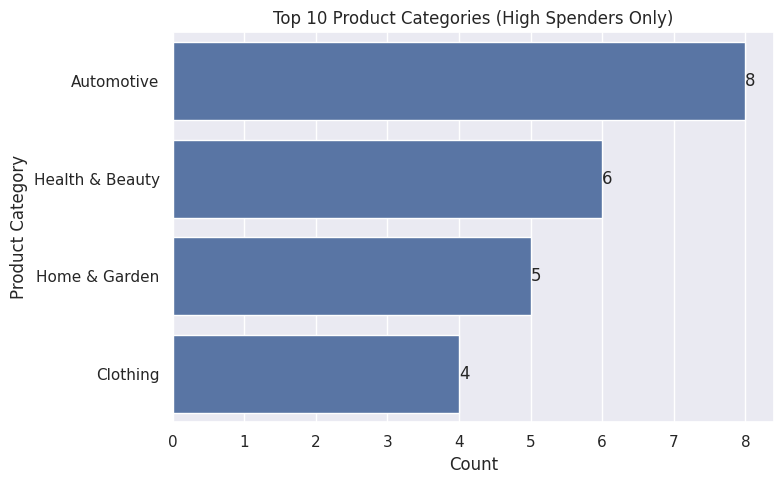

In [77]:
if "ProductCategory" in df_hs.columns:
    top_pc = (
        df_hs[df_hs[HS_COL]==1]
        .dropna(subset=["ProductCategory"])
        ["ProductCategory"].value_counts().head(10)
    )
    plt.figure(figsize=(8,5))
    ax = sns.barplot(x=top_pc.values, y=top_pc.index)
    ax.set_title("Top 10 Product Categories (High Spenders Only)")
    ax.set_xlabel("Count"); ax.set_ylabel("Product Category")
    for c in ax.containers:
        ax.bar_label(c)
    plt.tight_layout()
    plt.show()


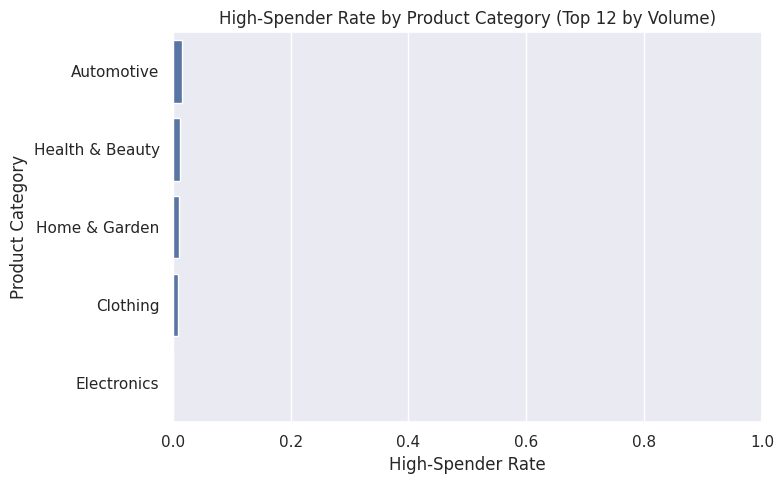

In [78]:
if "ProductCategory" in df_hs.columns:
    tmp = df_hs.dropna(subset=["ProductCategory"]).copy()
    pc_counts = tmp["ProductCategory"].value_counts()
    topN = pc_counts.head(12).index
    tmp = tmp[tmp["ProductCategory"].isin(topN)]

    rate = tmp.groupby("ProductCategory")[HS_COL].mean().sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    ax = sns.barplot(x=rate.values, y=rate.index)
    ax.set_title("High-Spender Rate by Product Category (Top 12 by Volume)")
    ax.set_xlabel("High-Spender Rate"); ax.set_ylabel("Product Category")
    ax.set_xlim(0,1)
    plt.tight_layout()
    plt.show()


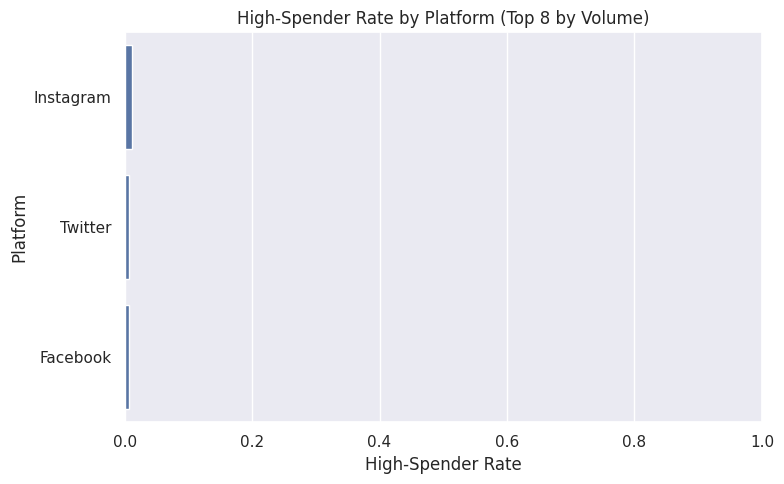

In [79]:
if "Platform" in df_hs.columns:
    tmp = df_hs.dropna(subset=["Platform"]).copy()
    topP = tmp["Platform"].value_counts().head(8).index
    tmp = tmp[tmp["Platform"].isin(topP)]

    rate = tmp.groupby("Platform")[HS_COL].mean().sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    ax = sns.barplot(x=rate.values, y=rate.index)
    ax.set_title("High-Spender Rate by Platform (Top 8 by Volume)")
    ax.set_xlabel("High-Spender Rate"); ax.set_ylabel("Platform")
    ax.set_xlim(0,1)
    plt.tight_layout()
    plt.show()


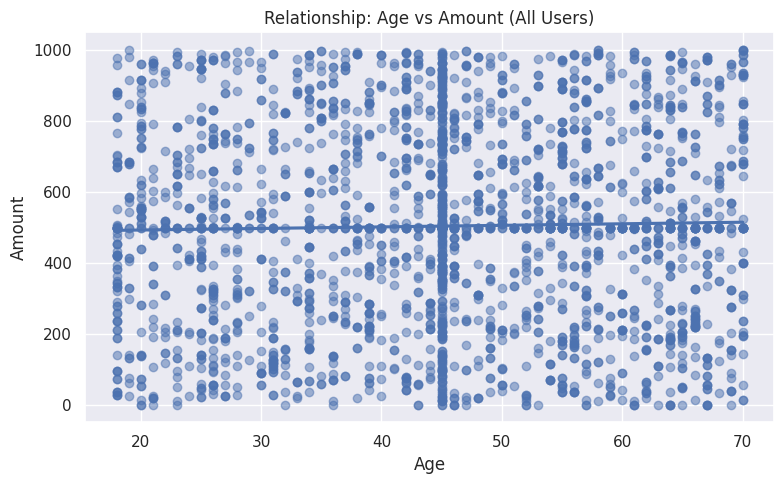

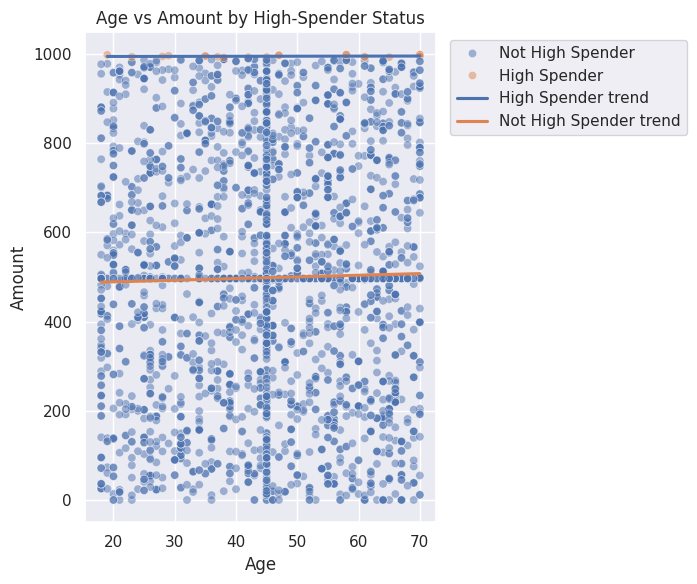

In [80]:
if "Age" in df_hs.columns:
    plt.figure(figsize=(8,5))
    ax = sns.regplot(data=df_hs, x="Age", y=AMOUNT_COL, scatter_kws={'alpha':0.5}, ci=None)
    ax.set_title("Relationship: Age vs Amount (All Users)")
    ax.set_xlabel("Age"); ax.set_ylabel("Amount")
    plt.tight_layout()
    plt.show()

    # Colored scatter with separate trend lines (one per HS status)
    plt.figure(figsize=(9,6))
    ax = sns.scatterplot(data=df_hs, x="Age", y=AMOUNT_COL, hue="HS_Label", alpha=0.5)
    # Add group-wise linear fits
    for k, sub in df_hs.groupby("HS_Label"):
        sns.regplot(data=sub, x="Age", y=AMOUNT_COL, scatter=False, ci=None, label=f"{k} trend")
    ax.set_title("Age vs Amount by High-Spender Status")
    ax.set_xlabel("Age"); ax.set_ylabel("Amount")
    # move legend outside
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="")
    plt.tight_layout(rect=[0,0,0.8,1])
    plt.show()


# Analysis

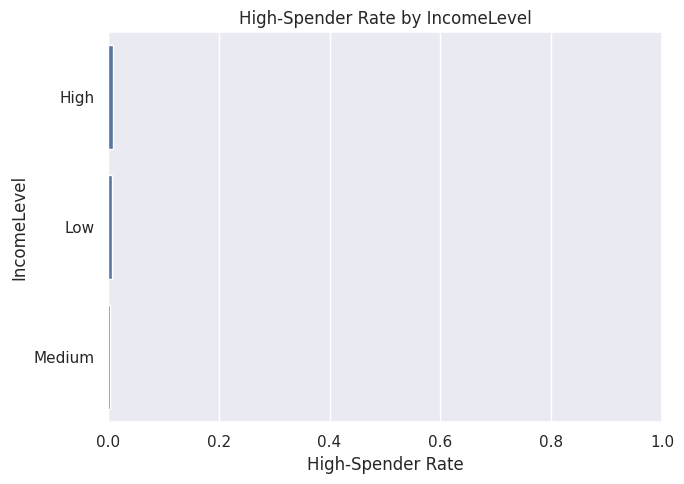

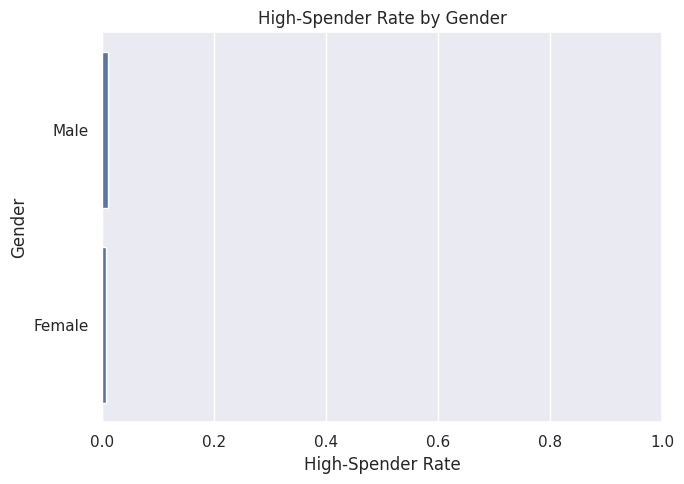

In [81]:
for dim in ["IncomeLevel","Gender"]:
    if dim in df_hs.columns:
        tmp = df_hs.dropna(subset=[dim]).copy()
        rate = tmp.groupby(dim)[HS_COL].mean().sort_values(ascending=False)
        plt.figure(figsize=(7,5))
        ax = sns.barplot(x=rate.values, y=rate.index)
        ax.set_title(f"High-Spender Rate by {dim}")
        ax.set_xlabel("High-Spender Rate"); ax.set_ylabel(dim)
        ax.set_xlim(0,1)
        plt.tight_layout()
        plt.show()


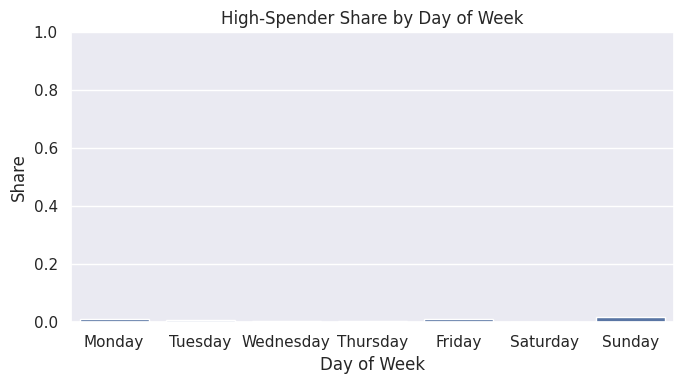

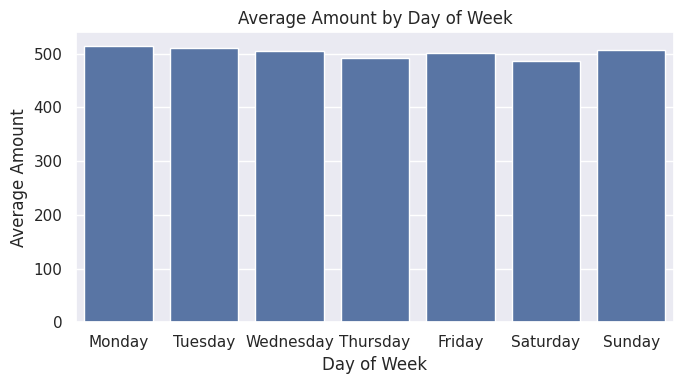

In [82]:
tmp = df_hs.set_index(DATE_COL).copy()
tmp["dow"] = tmp.index.day_name()

share_by_dow = tmp.groupby("dow")[HS_COL].mean()
avg_amt_by_dow = tmp.groupby("dow")[AMOUNT_COL].mean()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
share_by_dow = share_by_dow.reindex(order)
avg_amt_by_dow = avg_amt_by_dow.reindex(order)

plt.figure(figsize=(7,4))
ax = sns.barplot(x=share_by_dow.index, y=share_by_dow.values)
ax.set_title("High-Spender Share by Day of Week")
ax.set_xlabel("Day of Week"); ax.set_ylabel("Share")
ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
ax = sns.barplot(x=avg_amt_by_dow.index, y=avg_amt_by_dow.values)
ax.set_title("Average Amount by Day of Week")
ax.set_xlabel("Day of Week"); ax.set_ylabel("Average Amount")
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

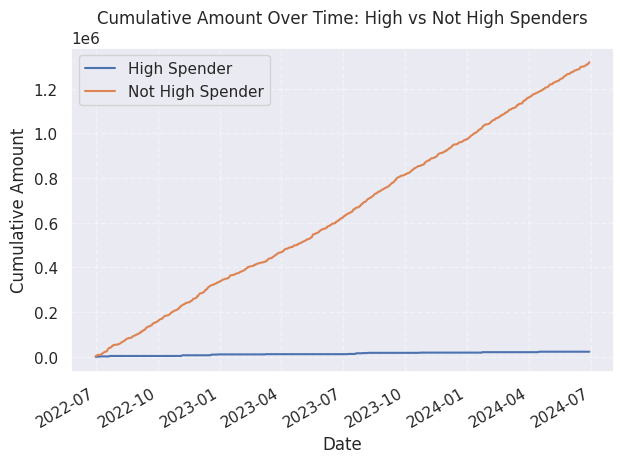

In [83]:
cum = (
    df_hs
    .set_index(DATE_COL)
    .groupby([pd.Grouper(freq="D"), "HS_Label"])[AMOUNT_COL]
    .sum()
    .unstack(fill_value=0)
    .cumsum()
)

plt.figure(figsize=(10,5))
ax = cum.plot()
ax.set_title("Cumulative Amount Over Time: High vs Not High Spenders")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative Amount")
plt.legend(title="")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
